# Global Warming — NASA Temperature Anomaly Data

Download and visualise NASA's Northern Hemisphere temperature anomaly dataset. We recreate the 'hockey stick' chart, density plots by historical interval, and ECDF comparisons.

**Source:** https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.txt  
**R original used:** tidyverse, GGally, skimr, mosaic  
**Python equivalents:** pandas, seaborn, matplotlib

In [ ]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

from statsmodels.nonparametric.smoothers_lowess import lowess



import warnings
warnings.filterwarnings('ignore')

# Global plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# --- Download NASA temperature anomaly data ---
# NASA publishes a CSV version of the same table; we skip the first header row
# and treat '***' as missing values (some months have not yet been recorded)

nasa_url = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.csv'

nasa_data = (
    pd.read_csv(
        nasa_url,
        skiprows=1,       # skip the first text header row
        na_values='***'   # NASA uses '***' for missing monthly data
    )
)

print('Raw data shape:', nasa_data.shape)
nasa_data.tail()

Raw data shape: (147, 19)


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
142,2022,1.24,1.16,1.41,1.09,1.02,1.13,1.07,1.17,1.15,1.32,1.09,1.06,1.16,1.17,1.19,1.17,1.12,1.19
143,2023,1.29,1.28,1.64,1.02,1.13,1.20,1.44,1.57,1.68,1.88,1.97,1.85,1.50,1.43,1.21,1.26,1.40,1.84
144,2024,1.67,1.92,1.78,1.79,1.45,1.54,1.42,1.43,1.58,1.73,1.89,1.70,1.66,1.67,1.82,1.67,1.46,1.74
145,2025,1.84,1.63,1.83,1.60,1.22,1.19,1.23,1.28,1.40,1.49,1.68,1.45,1.49,1.51,1.73,1.55,1.23,1.52
146,2026,1.39,1.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.48,NaN,NaN,NaN


In [4]:
# --- Reshape from wide to long (tidy) format ---
# The raw table has one row per year and one column per month.
# We want: date | year | month | delta

month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

global_warming_data = (
    nasa_data
    # Keep only Year + the 12 monthly columns
    [['Year'] + month_cols]
    # pivot_longer equivalent: melt months into a single 'month' column
    .melt(id_vars='Year', var_name='month', value_name='delta')
    # Construct a proper date by combining year + month abbreviation + '01'
    .assign(
        date=lambda df: pd.to_datetime(
            df['Year'].astype(str) + '-' + df['month'] + '-01',
            format='%Y-%b-%d'
        ),
        year=lambda df: df['date'].dt.year,
        month=lambda df: df['date'].dt.strftime('%b')   # keep 3-letter month label
    )
    # Keep only the columns we need, in a logical order
    [['date', 'year', 'month', 'delta']]
    # Remove rows with no temperature reading yet
    .dropna(subset=['delta'])
    # Sort chronologically
    .sort_values('date')
    .reset_index(drop=True)
)

print('Tidy data shape:', global_warming_data.shape)
global_warming_data.head(10)

Tidy data shape: (1754, 4)


,date,year,month,delta
0,1880-01-01,1880,Jan,-0.37
1,1880-02-01,1880,Feb,-0.53
2,1880-03-01,1880,Mar,-0.25
3,1880-04-01,1880,Apr,-0.31
4,1880-05-01,1880,May,-0.08
5,1880-06-01,1880,Jun,-0.18
6,1880-07-01,1880,Jul,-0.21
7,1880-08-01,1880,Aug,-0.28
8,1880-09-01,1880,Sep,-0.25
9,1880-10-01,1880,Oct,-0.33


In [5]:
# --- Assign historical intervals ---
# We split the data into 5 eras to compare how warming has accelerated over time
# Baseline period used by NASA: 1951-1980

def assign_interval(year):
    """Return the historical period label for a given year."""
    if year <= 1920:   return '1881-1920'
    elif year <= 1950: return '1921-1950'
    elif year <= 1980: return '1951-1980'
    elif year <= 2010: return '1981-2010'
    else:              return '2011-present'

global_warming_data = (
    global_warming_data
    .assign(interval=lambda df: df['year'].apply(assign_interval))
)

print('Records per interval:')
global_warming_data['interval'].value_counts().sort_index()

Records per interval:


interval
1881-1920       492
1921-1950       360
1951-1980       360
1981-2010       360
2011-present    182
Name: count, dtype: int64

In [6]:
# --- Summary statistics: delta by interval ---
# Equivalent to mosaic::favstats(delta ~ interval, data=global_warming_data)

(
    global_warming_data
    .groupby('interval')['delta']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .assign(se=lambda df: df['std'] / np.sqrt(df['count']))
    .round(3)
)

,count,mean,std,min,median,max,se
interval,,,,,,,
1881-1920,492,-0.350,0.232,-1.52,-0.350,0.33,0.010
1921-1950,360,-0.025,0.232,-0.80,-0.030,0.76,0.012
1951-1980,360,-0.000,0.198,-0.54,0.010,0.68,0.010
1981-2010,360,0.466,0.315,-0.42,0.475,1.45,0.017
2011-present,182,1.167,0.323,0.45,1.130,1.97,0.024


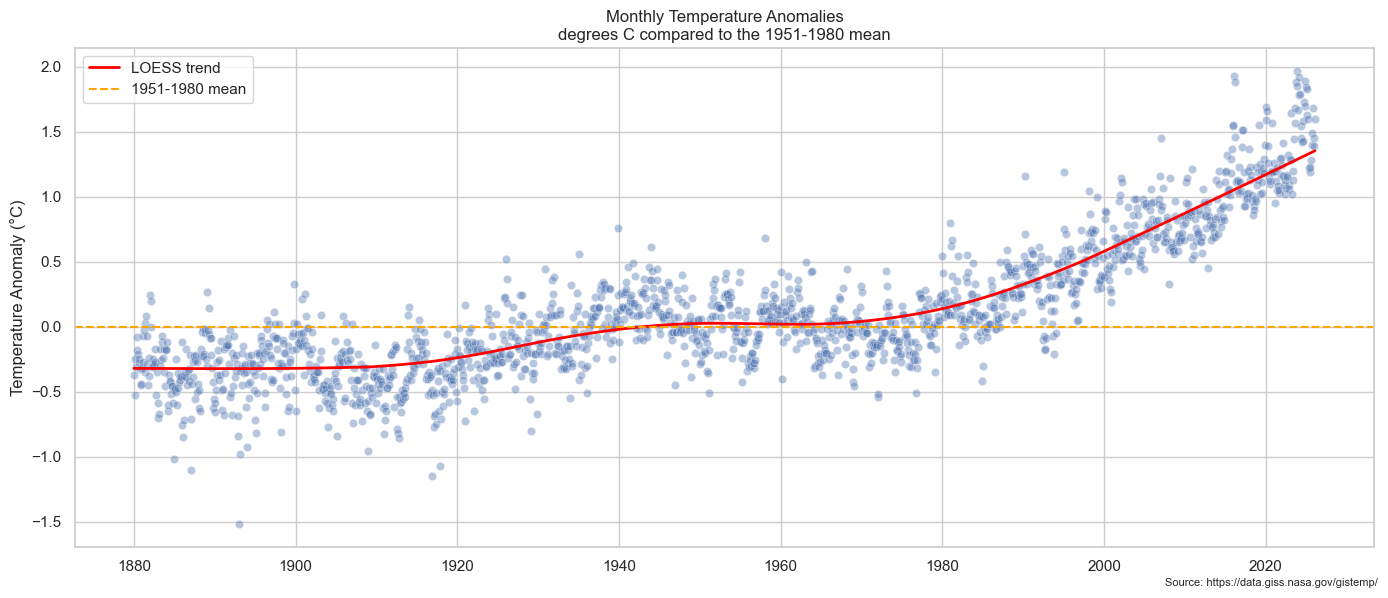

In [ ]:
# --- Hockey Stick plot ---
# Shows the dramatic upward trend in temperature anomaly over time
# Orange dashed line at y=0 is the 1951-1980 baseline

fig, ax = plt.subplots(figsize=(14, 6))

# Scatter of every monthly observation
sns.scatterplot(
    data=global_warming_data,
    x= 'date',
    y= 'delta',
    alpha = 0.4
)

smoothed = lowess(
    global_warming_data['delta'],
    global_warming_data['date'].map(pd.Timestamp.toordinal),
    frac=0.4        # smaller = tighter fit, larger = smoother
)

ax.plot(
    pd.to_datetime([pd.Timestamp.fromordinal(int(x)) for x in smoothed[:, 0]]),
    smoothed[:, 1],
    color='red', linewidth=2, label='LOESS trend'
)

# Horizontal baseline at zero
ax.axhline(0, color='orange', linewidth=1.5, linestyle='--', label='1951-1980 mean')

ax.set_xlabel('')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Monthly Temperature Anomalies\ndegrees C compared to the 1951-1980 mean')
ax.legend()
plt.figtext(0.99, 0.01, 'Source: https://data.giss.nasa.gov/gistemp/', ha='right', fontsize=8)
plt.tight_layout()
plt.show()

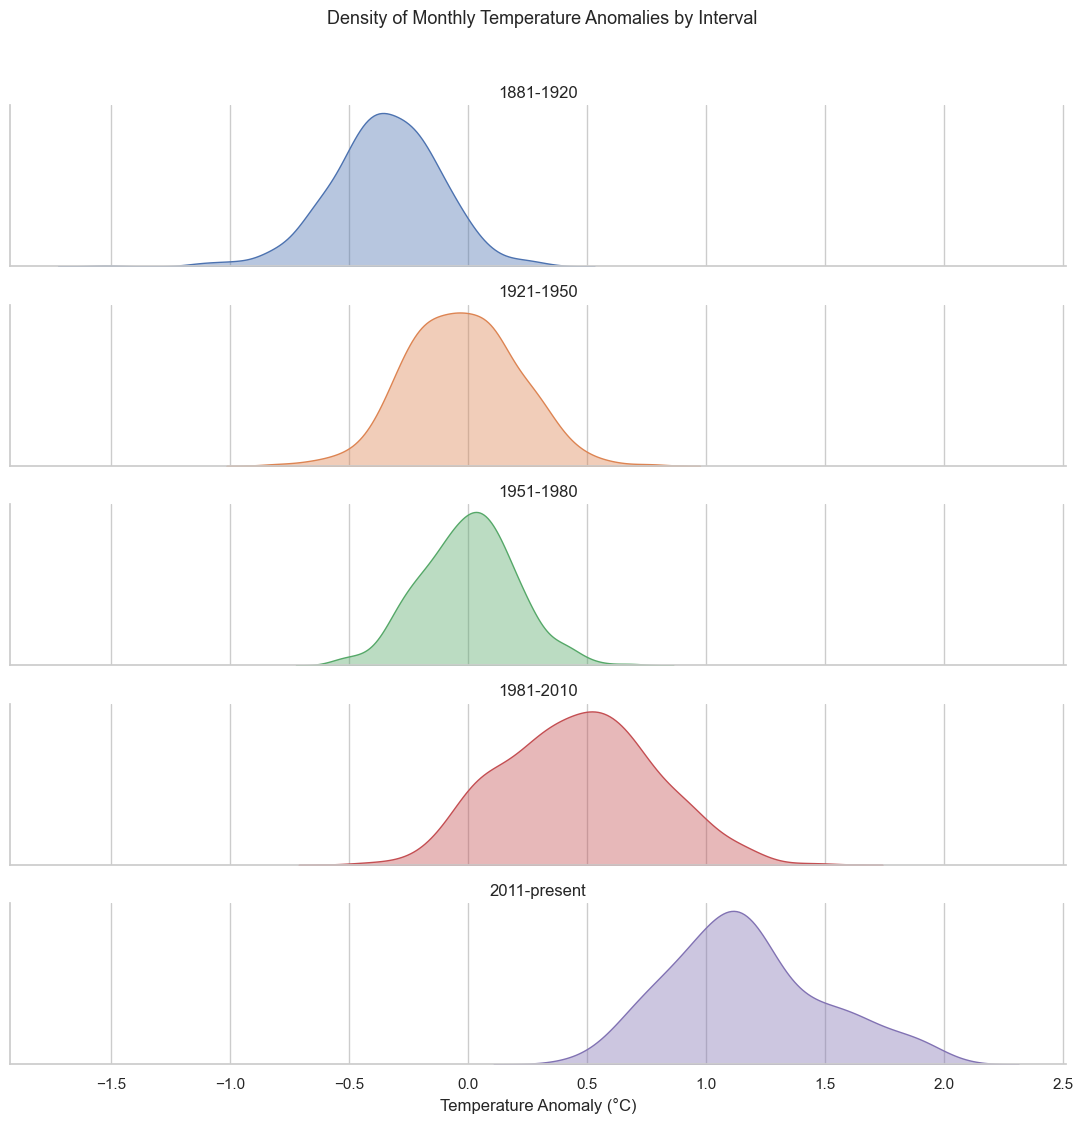

In [14]:
# --- Density plot of temperature anomalies, faceted by interval ---
# Shows how the distribution of monthly anomalies has shifted warmer over time

interval_order = ['1881-1920', '1921-1950', '1951-1980', '1981-2010', '2011-present']
global_warming_data['interval'] = pd.Categorical(
    global_warming_data['interval'], categories=interval_order, ordered=True
)

g = sns.FacetGrid(
    global_warming_data,
    row='interval',      # one row (subplot) per interval
    hue = 'interval',
    height=2.2,
    aspect=5,
    sharey=False         # allow each panel its own y-scale (mirroring scales='free' in R)
)

g.map(sns.kdeplot, 'delta', fill=True, alpha=0.4)
g.set_axis_labels('Temperature Anomaly (°C)', '')
g.set_titles(row_template='{row_name}')
g.figure.suptitle('Density of Monthly Temperature Anomalies by Interval', y=1.02, fontsize=13)

# Remove y-axis tick labels (density values are not meaningful here)
for ax in g.axes.flatten():
    ax.set_yticks([])

plt.tight_layout()
plt.show()

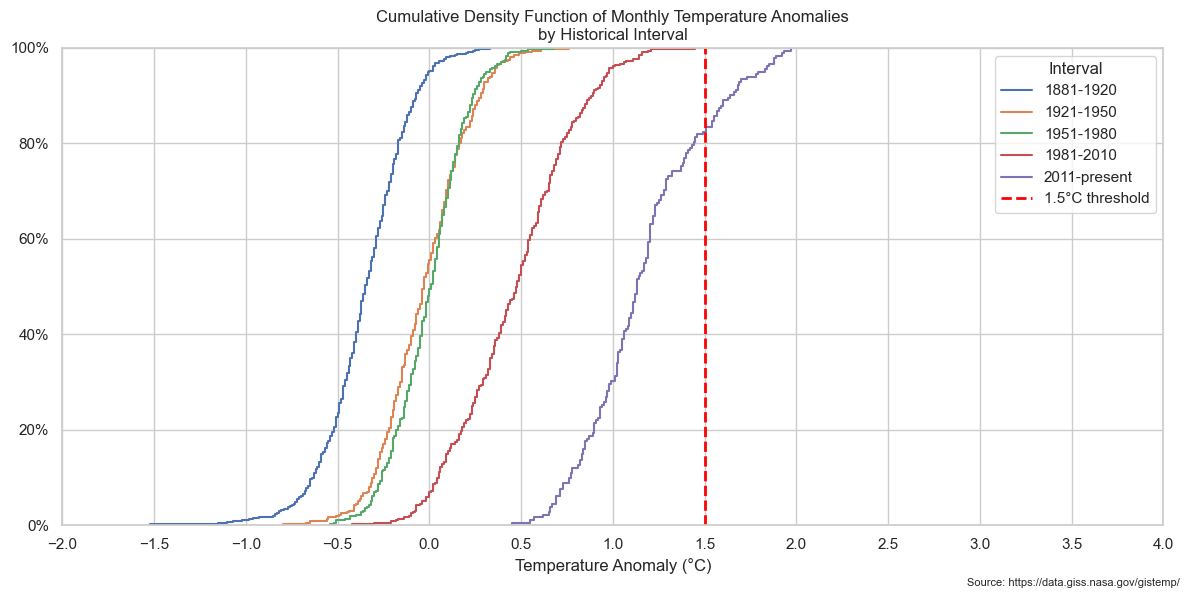

In [15]:
# --- ECDF (Empirical Cumulative Distribution Function) by interval ---
# The vertical red line at 1.5°C marks the Paris Agreement warming target.
# We can read off: what % of months in each era exceeded 1.5°C?

fig, ax = plt.subplots(figsize=(12, 6))

# Draw one ECDF per interval using seaborn
for interval, grp in (
    global_warming_data
    .sort_values('interval')         # ensures consistent colour order
    .groupby('interval', observed=True)
):
    sns.ecdfplot(
        data=grp,
        x='delta',
        ax=ax,
        label=interval
    )

# Paris Agreement 1.5°C target line
ax.axvline(1.5, color='red', linewidth=2, linestyle='--', label='1.5°C threshold')

# Format axes
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(np.arange(-2, 4.5, 0.5))
ax.set_xlabel('Temperature Anomaly (°C)')
ax.set_ylabel('')
ax.set_title('Cumulative Density Function of Monthly Temperature Anomalies\nby Historical Interval')
ax.legend(title='Interval')
plt.figtext(0.99, 0.01, 'Source: https://data.giss.nasa.gov/gistemp/', ha='right', fontsize=8)
plt.tight_layout()
plt.show()